Loading model and processing: image202601140001.jpg...
Using device: cpu


Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Inference complete. Converting colors...
Generating individual maps for all 19 categories...
Displaying results...


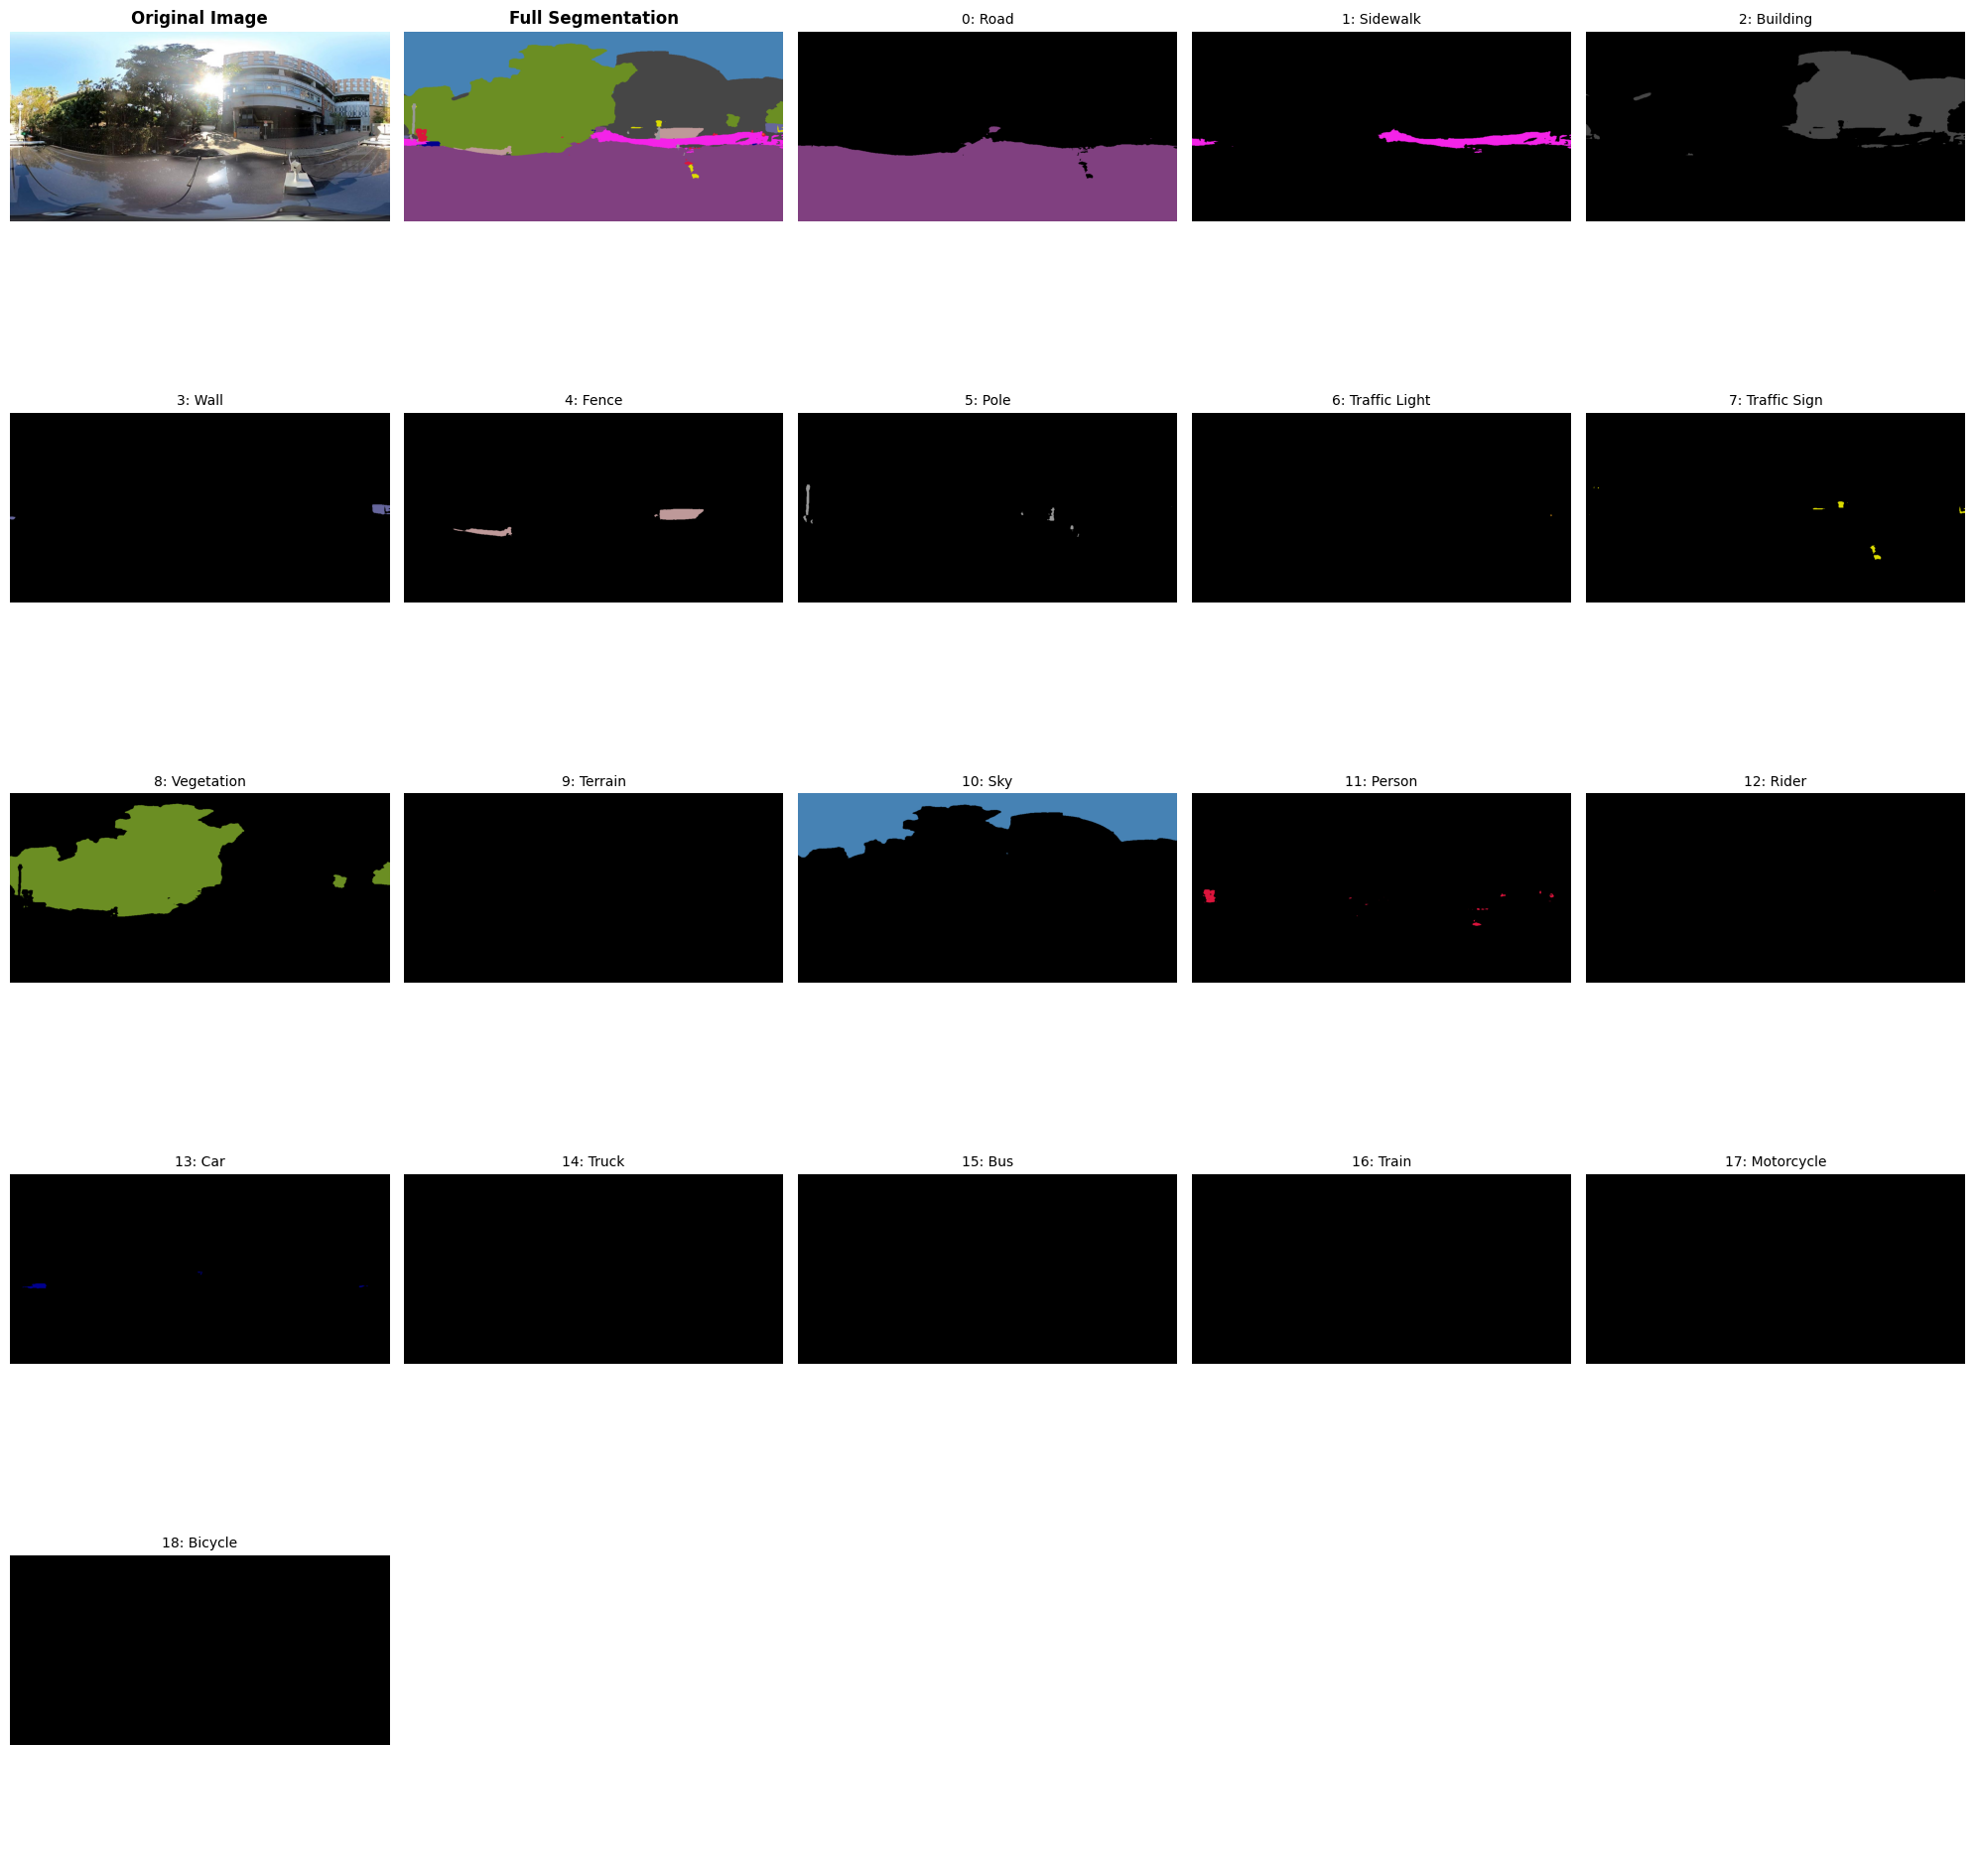

In [4]:
import torch
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ==============================================
# 1. Define Cityscapes Constants (Classes & Colors)
# ==============================================
CITYSCAPES_CLASSES = [
    'road', 'sidewalk', 'building', 'wall', 'fence', 'pole',
    'traffic light', 'traffic sign', 'vegetation', 'terrain', 'sky',
    'person', 'rider', 'car', 'truck', 'bus', 'train', 'motorcycle', 'bicycle'
]

# Official Cityscapes RGB Palette
# Index 19 added as solid black for background/void pixels.
CITYSCAPES_PALETTE = np.array([
    [128, 64, 128],  # 0: road
    [244, 35, 232],  # 1: sidewalk
    [70, 70, 70],    # 2: building
    [102, 102, 156], # 3: wall
    [190, 153, 153], # 4: fence
    [153, 153, 153], # 5: pole
    [250, 170, 30],  # 6: traffic light
    [220, 220, 0],   # 7: traffic sign
    [107, 142, 35],  # 8: vegetation
    [152, 251, 152], # 9: terrain
    [70, 130, 180],  # 10: sky
    [220, 20, 60],   # 11: person
    [255, 0, 0],     # 12: rider
    [0, 0, 142],     # 13: car
    [0, 0, 70],      # 14: truck
    [0, 60, 100],    # 15: bus
    [0, 80, 100],    # 16: train
    [0, 0, 230],     # 17: motorcycle
    [119, 11, 32],   # 18: bicycle
    [0, 0, 0]        # 19: VOID/Background
], dtype=np.uint8)


# ==============================================
# 2. Helper Functions
# ==============================================
def convert_indices_to_color(seg_map_int):
    """Converts a 2D integer map to a 3D RGB image using the palette."""
    safe_map = seg_map_int.copy()
    safe_map[safe_map > 18] = 19
    return CITYSCAPES_PALETTE[safe_map]

def get_isolated_colored_map(seg_map_int, class_idx, full_color_rgb):
    """Creates an image showing ONLY the specific class color, everything else black."""
    mask = (seg_map_int == class_idx)
    isolated_img = np.zeros_like(full_color_rgb)
    isolated_img[mask] = full_color_rgb[mask]
    return isolated_img

# ==============================================
# 3. Main Processing Function
# ==============================================
def process_image(image_path):
    print(f"Loading model and processing: {image_path}...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load Model (using the high-quality b5 version)
    model_name = "nvidia/segformer-b5-finetuned-cityscapes-1024-1024"
    try:
        processor = SegformerImageProcessor.from_pretrained(model_name)
        model = SegformerForSemanticSegmentation.from_pretrained(model_name).to(device)
    except Exception as e:
        raise RuntimeError(f"Failed to load model. Check internet connection.\nDetails: {e}")

    # Load and Preprocess Image
    image = Image.open(image_path).convert("RGB")
    original_size = image.size[::-1] # H, W
    inputs = processor(images=image, return_tensors="pt").to(device)

    # Inference
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    # Upsample to original size
    upsampled_logits = torch.nn.functional.interpolate(
        logits, size=original_size, mode="bilinear", align_corners=False
    )

    # Get integer segmentation map (H x W)
    seg_map_int = upsampled_logits.argmax(dim=1)[0].cpu().numpy()

    print("Inference complete. Converting colors...")
    full_color_seg_img = convert_indices_to_color(seg_map_int)

    return np.array(image), seg_map_int, full_color_seg_img


# ==============================================
# 4. Execution and Visualization (Displaying ALL)
# ==============================================
input_image_filename = "image202601140001.jpg" # Ensure this matches your file

try:
    # Run the processing pipeline
    orig_img, seg_int_map, full_color_map = process_image(input_image_filename)

    num_classes = len(CITYSCAPES_CLASSES) # 19
    total_plots = 2 + num_classes # Original + Full Seg + 19 classes = 21 plots

    # --- Setup Matplotlib Grid ---
    # A 5x5 grid gives 25 slots, enough for our 21 plots.
    rows, cols = 5, 5
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(20, 20))
    axes = axes.flatten()

    # 1. Plot Original Image
    axes[0].imshow(orig_img)
    axes[0].set_title("Original Image", fontweight='bold')
    axes[0].axis('off')

    # 2. Plot Full Colored Segmentation
    axes[1].imshow(full_color_map)
    axes[1].set_title("Full Segmentation", fontweight='bold')
    axes[1].axis('off')

    # 3. Plot ALL 19 Isolated Feature Maps
    plot_idx = 2
    print(f"Generating individual maps for all {num_classes} categories...")

    # Iterate through ALL category indices (0 to 18)
    for class_idx in range(num_classes):
        class_name = CITYSCAPES_CLASSES[class_idx]
        
        # Generate the isolated colored map for this class
        isolated_map = get_isolated_colored_map(seg_int_map, class_idx, full_color_map)
        
        # Plotting
        axes[plot_idx].imshow(isolated_map)
        # Include index in title for easy reference
        axes[plot_idx].set_title(f"{class_idx}: {class_name.title()}", fontsize=10)
        axes[plot_idx].axis('off')
        plot_idx += 1

    # Hide any remaining unused subplots in the 5x5 grid
    for i in range(plot_idx, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    print("Displaying results...")
    plt.show()

except Exception as e:
    print(f"\nAn error occurred:\n{e}")